<a href="https://colab.research.google.com/github/guzik1234/DataScienceCwiczenia/blob/main/python_pandas/GoogleApssData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

df= pd.read_csv('googleplaystore.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [5]:

df.columns = [col.replace(' ', '_') for col in df.columns ]
col = [col for col in df.columns]

In [6]:
df = df.drop(10472, errors='ignore')
df = df.reset_index(drop=True)

In [7]:
df = df.drop(10472, errors='ignore')
df = df.reset_index(drop=True)
display(df.head())

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content_Rating,Genres,Last_Updated,Current_Ver,Android_Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [8]:
df.Reviews = pd.to_numeric(df.Reviews)

In [14]:
tmp = df.groupby('Category').size().rename('Count')

<Axes: title={'center': 'categories'}, xlabel='Category'>

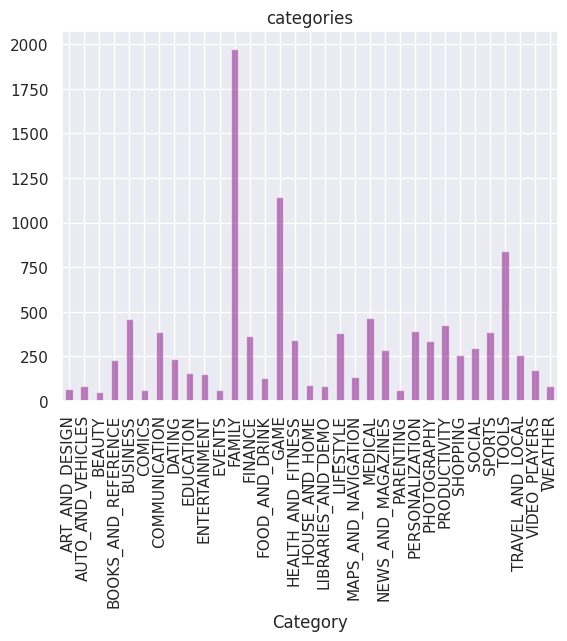

In [16]:
tmp.plot(kind='bar', color='purple', alpha=0.5, title='categories')

<Axes: ylabel='Clount'>

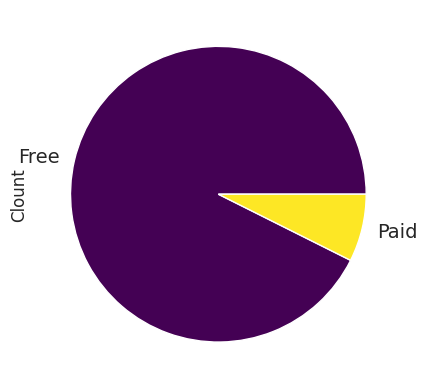

In [18]:
tmp = df.groupby('Type').size().rename('Clount')
tmp.plot(kind='pie', cmap='viridis', fontsize=14)

array([<Axes: title={'center': 'Rating_count'}, xlabel='Genres,Type'>,
       <Axes: title={'center': 'Rating_mean'}, xlabel='Genres,Type'>],
      dtype=object)

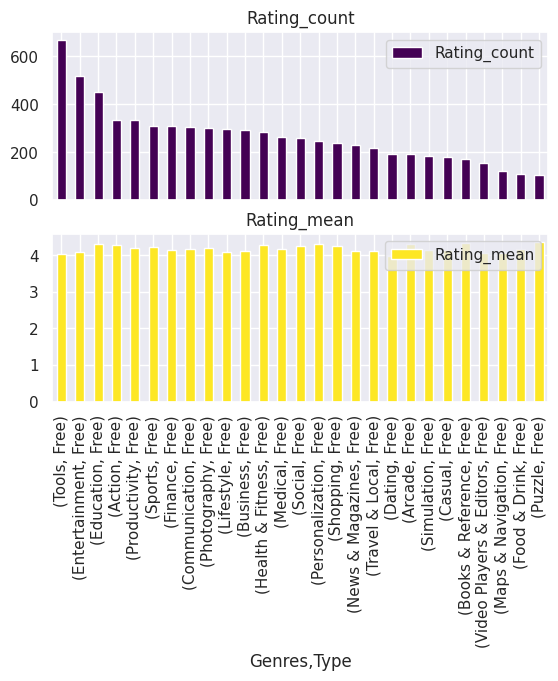

In [23]:
df = df[['Genres', 'Rating', 'Type']]
tmp = df.groupby(['Genres', 'Type']).agg({'Rating':['count', 'mean']})
tmp.columns = ['_'.join(x) for x in tmp.columns.ravel()]
tmp = tmp.sort_values('Rating_count', ascending=False)
tmp = tmp[tmp['Rating_count'] > 100]
tmp.plot(kind='bar', cmap='viridis', subplots=True)

<Axes: ylabel='Rating_count'>

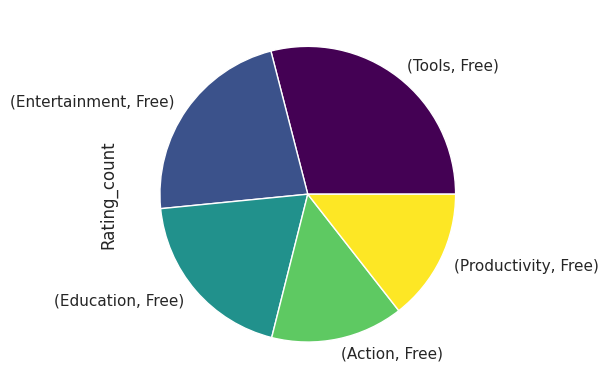

In [28]:
top_5 = tmp.nlargest(5, columns='Rating_count')['Rating_count']
top_5.plot(kind='pie', cmap='viridis')